# Import Libraries

In [127]:
# Download dataset from Kaggle
import kagglehub

# Work with file paths and directories
import os

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Statistical data visualization
import seaborn as sns

# Data preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Clustering
from sklearn.cluster import KMeans

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Load the Dataset

In [128]:
path = kagglehub.dataset_download("harshadapatil31/student-performance-and-study-habits-dataset")
df = pd.read_csv(os.path.join(path, 'student_performance_dataset.csv'))

# Dataset Overview

In [129]:
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [130]:
df.shape

(1000, 12)

In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


In [132]:
df.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


In [133]:
df.isnull().sum()

student_id                      0
gender                          0
study_time_hours                0
attendance_percent              0
sleep_hours                     0
parental_education            102
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
final_exam_score                0
final_grade                     0
dtype: int64

In [134]:
df.duplicated().sum()

np.int64(0)

Observation:
The dataset contains both numerical and categorical features. A small number of missing values were found in the parental_education column, while no duplicated records were detected.

# Data Cleaning

In [135]:
df['parental_education'].dtype

dtype('O')

In [136]:
df['parental_education'] = df['parental_education'].fillna(
    df['parental_education'].mode()[0]
)

In [137]:
df.isnull().sum()

student_id                    0
gender                        0
study_time_hours              0
attendance_percent            0
sleep_hours                   0
parental_education            0
internet_access               0
extracurricular_activities    0
part_time_job                 0
previous_grade                0
final_exam_score              0
final_grade                   0
dtype: int64

In [138]:
df = df.drop(columns=['student_id', 'final_grade'])

Observation:
Missing values in the parental_education column were replaced with the most frequent category (mode). In addition, the student_id column was removed because it is only an identifier, and final_grade was excluded to prevent potential data leakage and avoid redundancy during clustering.

# Exploratory Data Analysis (EDA)

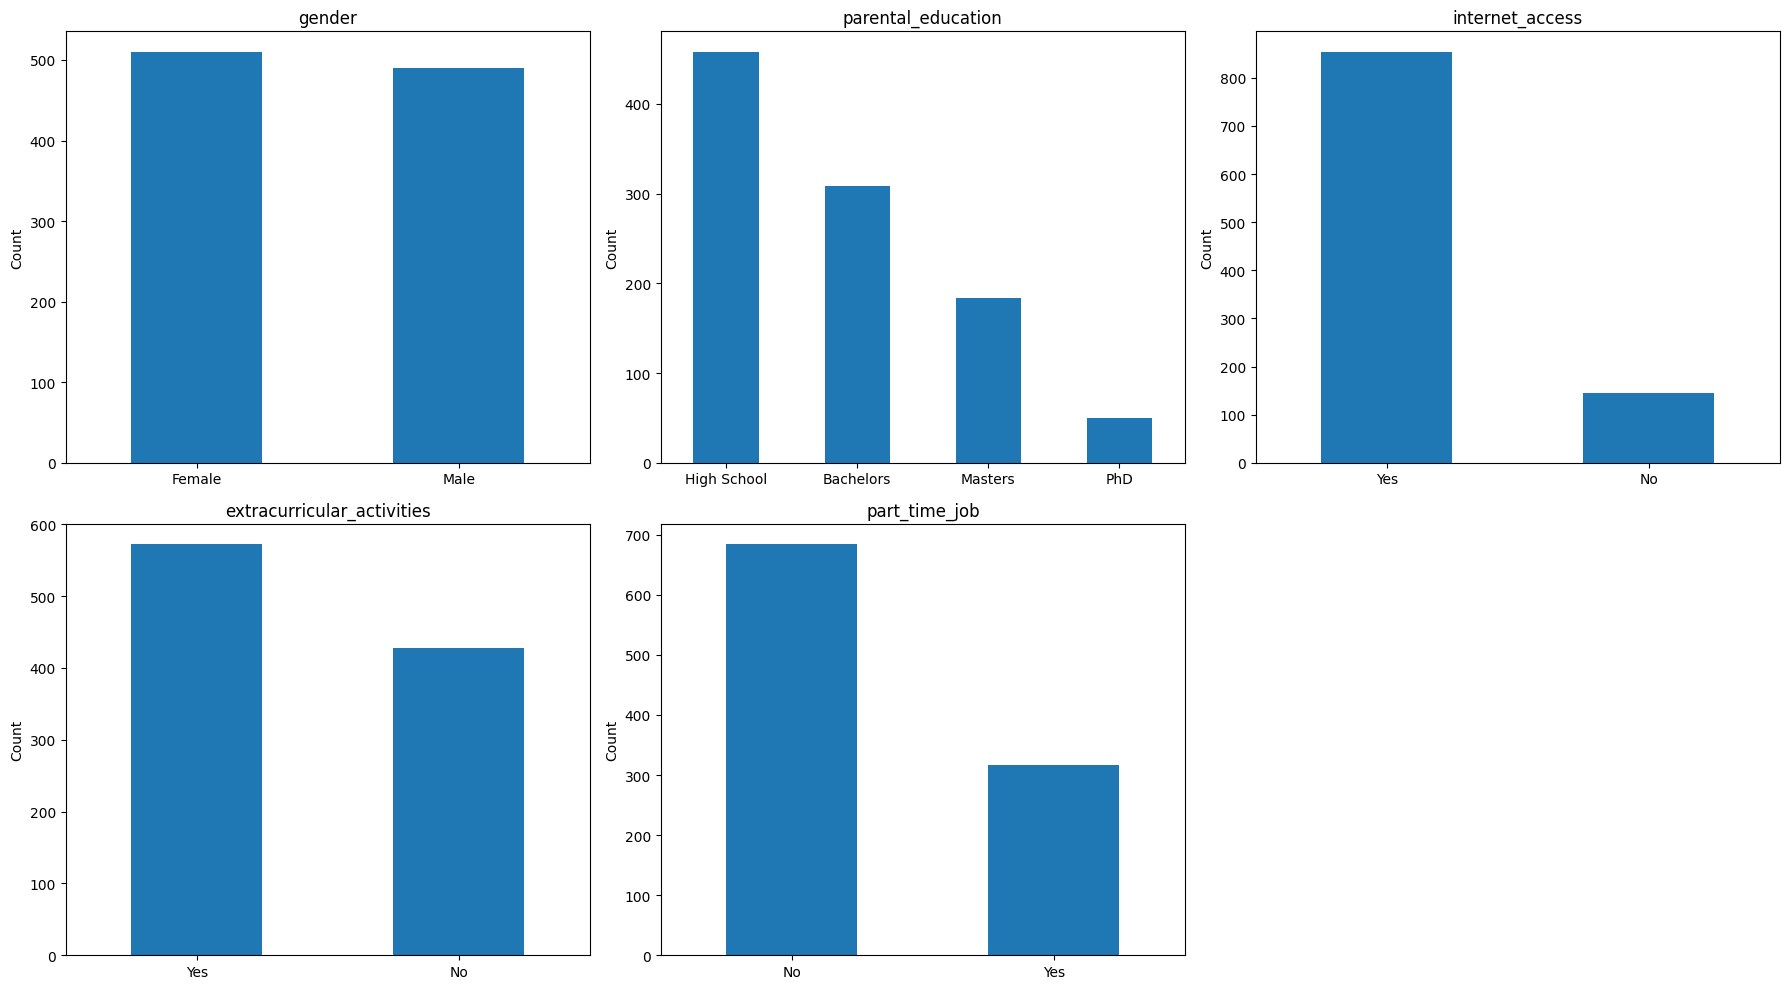

In [139]:
categorical_cols = df.select_dtypes(include='object').columns

n_cols = 3
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])

    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=0)

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


- Gender
Observation: The number of male and female students is nearly balanced, indicating no significant gender imbalance in the dataset.

- Parental Education
Observation: Most students' parents have a High School education, followed by Bachelor's. Master's and PhD degrees are less common.

- Internet Access
Observation: The majority of students have internet access, while only a small portion do not.

- Extracurricular Activities
Observation: More students participate in extracurricular activities than those who do not.

- Part-time Job
Observation: Most students do not have a part-time job, while a smaller group works part-time.

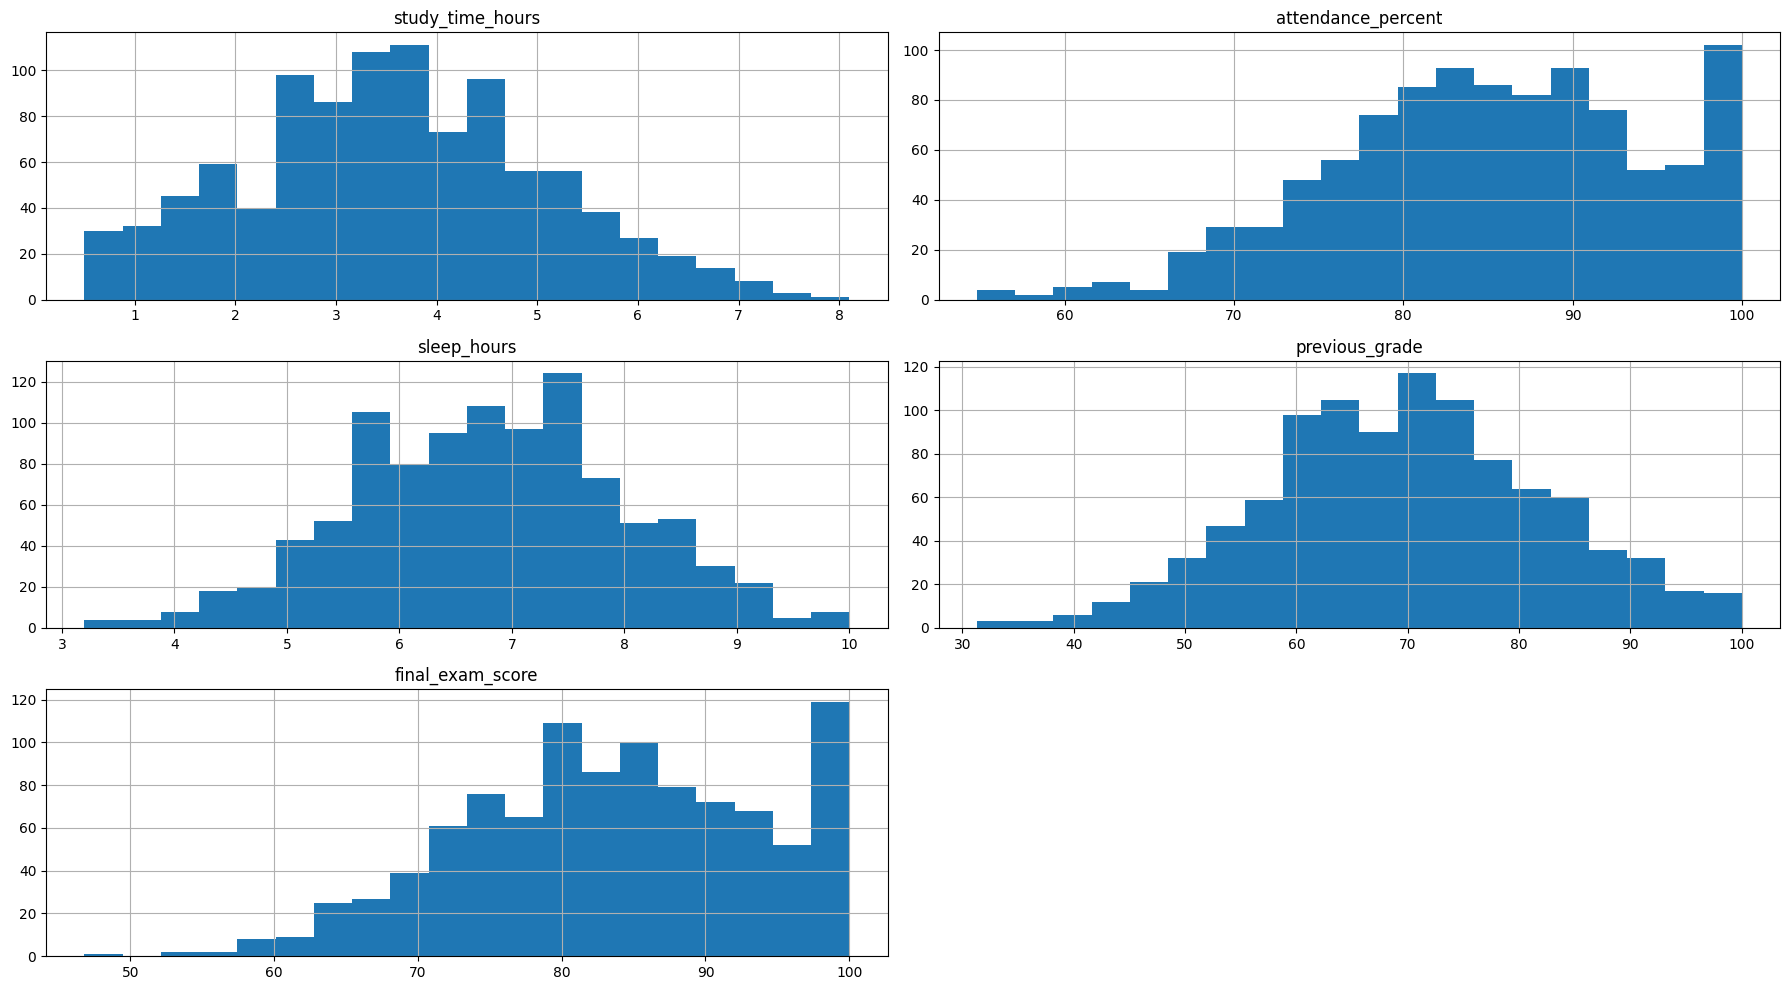

In [140]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numerical_cols].hist(figsize=(18,10), bins=20)

plt.tight_layout()
plt.show()


- Study Time Hours
Observation: Most students study between 3 and 5 hours per day, while very short and very long study times are less common.

- Attendance Percent
Observation: Most students have high attendance, with many students attending more than 75% of classes.

- Sleep Hours
Observation: The majority of students sleep between 6 and 8 hours, suggesting a fairly consistent sleeping pattern.

- Previous Grade
Observation: Previous grades are concentrated around 60–80, with fewer students having very low or very high grades.

- Final Exam Score
Observation: Most final exam scores are relatively high, with many students scoring between 75 and 95, indicating generally good academic performance.

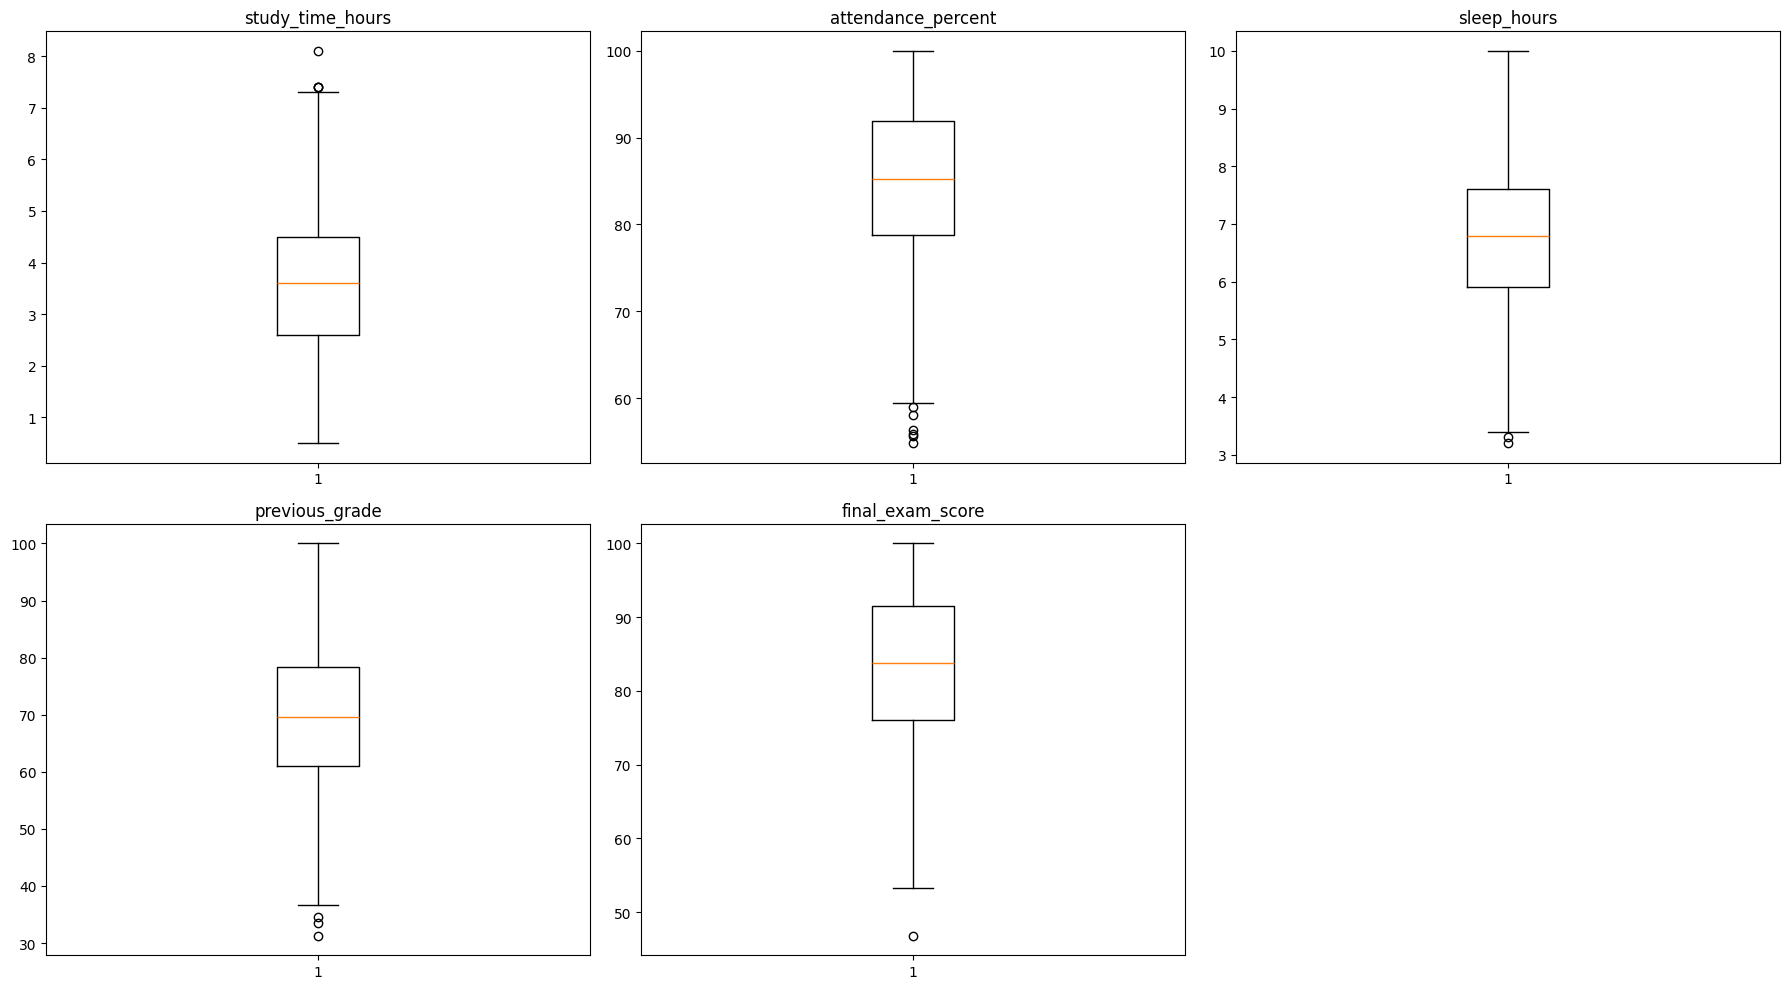

In [ ]:
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)

for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- Study Time Hours
Observation: Most students study around 3–4 hours, with a few students studying significantly more than the rest.

- Attendance Percent
Observation: Attendance is generally high, although a small number of students have noticeably lower attendance rates.

- Sleep Hours
Observation: Most students sleep between 6 and 8 hours, with only a few observations at the lower end of the range.

- Previous Grade
Observation: Previous grades are concentrated around the middle range, with a small number of low-score outliers.

- Final Exam Score
Observation: Most final exam scores are relatively high, with only a few low-score outliers.

# Data Preprocessing

In [142]:
binary_cols = [
    'internet_access',
    'extracurricular_activities',
    'part_time_job'
]

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [143]:
df.head()

,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score
0,Male,4.0,98.0,6.5,Bachelors,1,1,0,76.9,100.0
1,Female,6.3,100.0,5.7,High School,1,1,1,75.5,100.0
2,Male,4.9,85.3,7.9,Bachelors,1,0,1,88.5,97.3
3,Male,2.6,77.5,8.0,High School,1,1,0,85.1,83.8
4,Male,2.2,89.6,4.6,Bachelors,1,0,1,61.8,68.3


In [144]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   gender                      1000 non-null   int64  
 1   study_time_hours            1000 non-null   float64
 2   attendance_percent          1000 non-null   float64
 3   sleep_hours                 1000 non-null   float64
 4   parental_education          1000 non-null   int64  
 5   internet_access             1000 non-null   int64  
 6   extracurricular_activities  1000 non-null   int64  
 7   part_time_job               1000 non-null   int64  
 8   previous_grade              1000 non-null   float64
 9   final_exam_score            1000 non-null   float64
dtypes: float64(5), int64(5)
memory usage: 78.2 KB


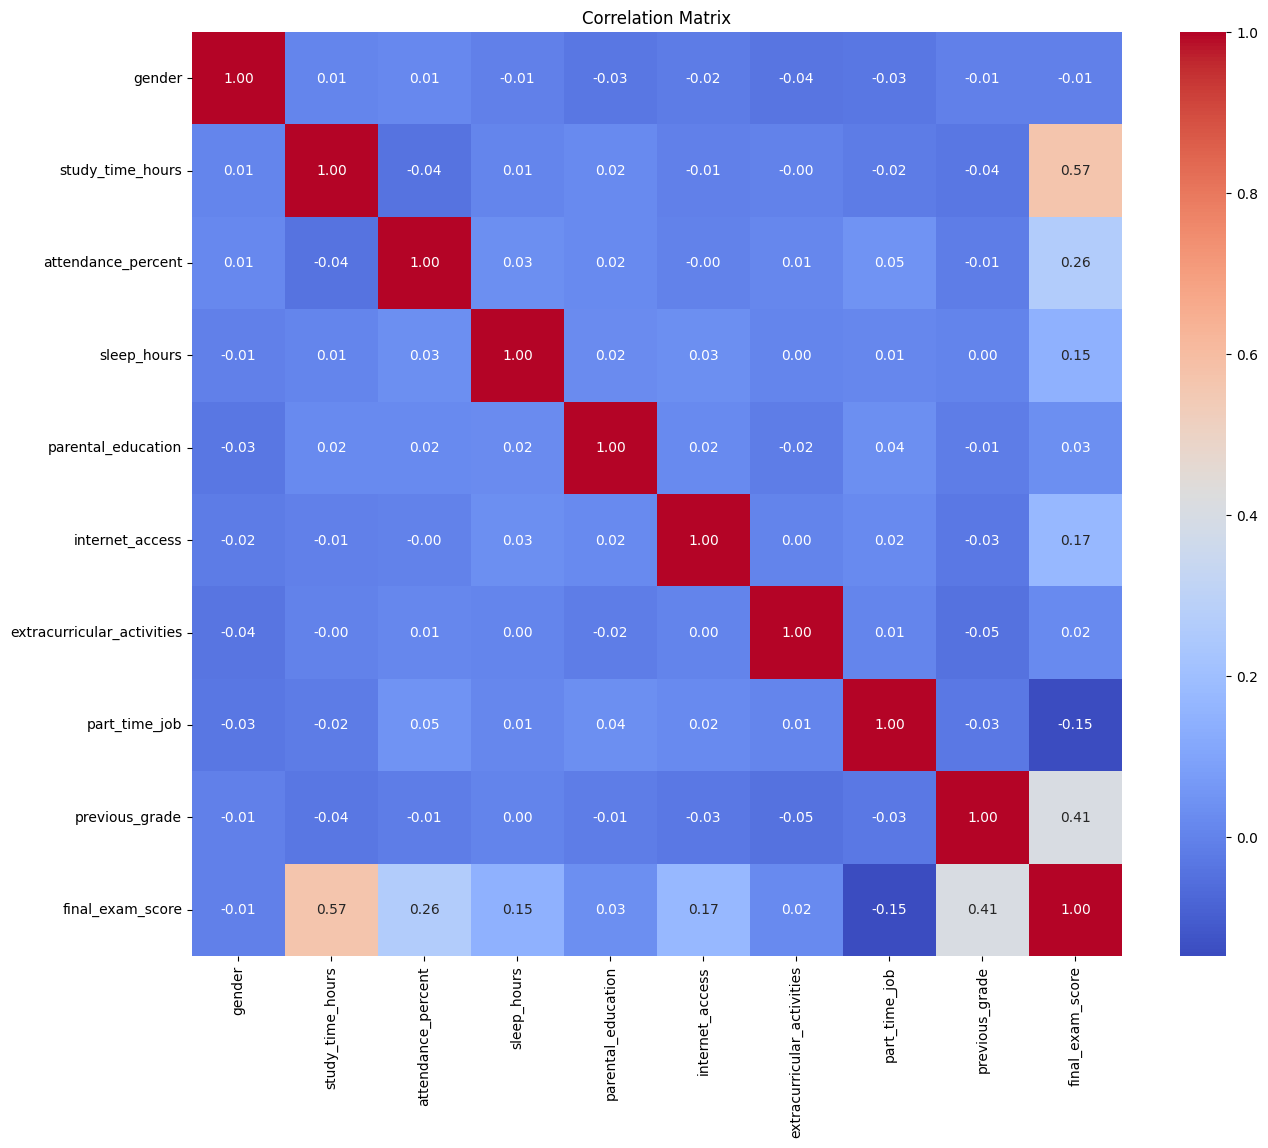

In [146]:
plt.figure(figsize=(15, 12))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

Observation:
The correlation matrix shows that study_time_hours has the strongest positive correlation with final_exam_score (0.57), followed by previous_grade (0.41). Most other feature pairs have weak correlations, indicating limited linear relationships among the variables.

In [147]:
X = df.copy()

In [148]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# K-Means Clustering Before PCA

In [149]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

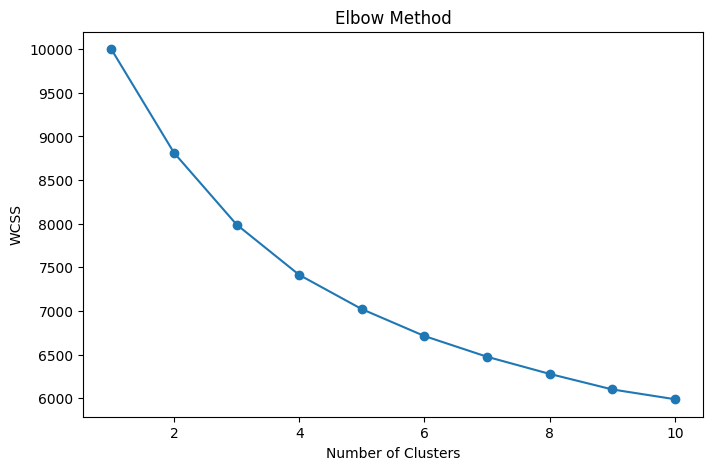

In [150]:
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

The **elbow** point suggests that 4 clusters is the optimal choice

In [151]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

df.head()

,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,Cluster
0,1,4.0,98.0,6.5,0,1,1,0,76.9,100.0,1
1,0,6.3,100.0,5.7,1,1,1,1,75.5,100.0,1
2,1,4.9,85.3,7.9,0,1,0,1,88.5,97.3,1
3,1,2.6,77.5,8.0,1,1,1,0,85.1,83.8,2
4,1,2.2,89.6,4.6,0,1,0,1,61.8,68.3,0


In [152]:
df['Cluster'].value_counts()

Cluster
2    359
1    275
0    221
3    145
Name: count, dtype: int64

In [153]:
cluster_summary = df.groupby('Cluster').mean().round(2)
cluster_summary

,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score
Cluster,,,,,,,,,,
0,0.46,3.13,85.03,6.75,0.99,1.0,0.55,1.00,68.35,79.11
1,0.52,4.77,88.14,7.05,1.04,1.0,0.63,0.19,75.52,95.25
2,0.48,2.93,82.81,6.69,0.93,1.0,0.54,0.00,65.81,79.09
3,0.52,3.56,85.06,6.68,0.94,0.0,0.57,0.30,70.62,79.12


In [154]:
cluster_names = {
    0: "Working Students",
    1: "High Achievers",
    2: "Low Study Time Students",
    3: "Limited Internet Access"
}

cluster_summary = df.groupby('Cluster').mean().round(2)
cluster_summary['Cluster_Name'] = cluster_summary.index.map(cluster_names)

cluster_summary = cluster_summary[['Cluster_Name'] + [col for col in cluster_summary.columns if col != 'Cluster_Name']]

cluster_summary

,Cluster_Name,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score
Cluster,,,,,,,,,,,
0,Working Students,0.46,3.13,85.03,6.75,0.99,1.0,0.55,1.00,68.35,79.11
1,High Achievers,0.52,4.77,88.14,7.05,1.04,1.0,0.63,0.19,75.52,95.25
2,Low Study Time Students,0.48,2.93,82.81,6.69,0.93,1.0,0.54,0.00,65.81,79.09
3,Limited Internet Access,0.52,3.56,85.06,6.68,0.94,0.0,0.57,0.30,70.62,79.12



**Cluster 0 – Working Students**

> **Cluster 0 (Working Students)** represents students with **moderate academic performance**. They study an average of **3.13 hours per day** and have an attendance rate of **85%**. Almost all students in this cluster have internet access, and all of them work part-time. Their average final exam score is **79.1**, indicating an average level of academic performance.

---

**Cluster 1 – High Achievers**

> **Cluster 1 (High-Performing Students)** represents the **highest-performing students**. They study the most (**4.77 hours per day**), have the highest attendance rate (**88.1%**), and achieve the highest previous grades and final exam scores (**95.3**). Most students in this cluster have internet access and do not work part-time, reflecting strong academic performance.

---

**Cluster 2 – Low Study Engagement**

> **Cluster 2 (Low Study Engagement)** includes students who study the least (**2.93 hours per day**) and have the lowest attendance rate (**82.8%**). Although most students have internet access and do not work part-time, their academic performance remains moderate, with an average final exam score of **79.1**.

---

**Cluster 3 – Limited Internet Access**

> **Cluster 3 (Limited Internet Access)** is mainly distinguished by the lack of internet access. Students in this cluster study an average of **3.56 hours per day**, have an attendance rate of **85%**, and achieve a moderate final exam score (**79.1**). Limited internet access is the most noticeable characteristic that differentiates this cluster from the others.

---

**Additional Observation**

> **Gender, sleep hours, parental education, and extracurricular activities showed very similar average values across all clusters. Therefore, these variables did not significantly contribute to distinguishing the clusters.**

# Principal Component Analysis (PCA)

In [155]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [156]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Explained Variance:", pca.explained_variance_ratio_.sum())

Explained Variance Ratio: [0.17715118 0.11276247]
Total Explained Variance: 0.2899136487333332


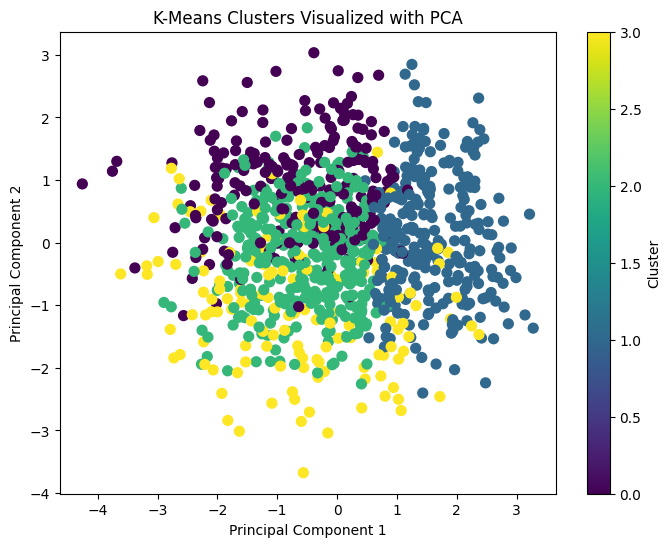

In [157]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['Cluster'],
    cmap='viridis',
    s=50
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters Visualized with PCA")

plt.colorbar(label="Cluster")

plt.show()

The PCA visualization shows that the clusters have partial separation, but there is still noticeable overlap between them. This is expected because the first two principal components explain only about 29% of the total variance. Therefore, the two-dimensional visualization captures only part of the data structure, while the remaining information is distributed across the other principal components.

# K-Means Clustering After PCA

In [158]:
kmeans_pca = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters_pca = kmeans_pca.fit_predict(X_pca)

In [159]:
df['Cluster_PCA'] = clusters_pca

In [160]:
cluster_summary_pca = df.groupby("Cluster_PCA").mean().round(2)
cluster_summary_pca

,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,Cluster
Cluster_PCA,,,,,,,,,,,
0,0.60,4.74,85.85,6.86,0.84,0.85,0.53,0.08,79.65,94.74,1.32
1,0.38,2.56,84.30,6.77,1.07,0.88,0.67,0.53,60.85,73.33,1.27
2,0.68,3.07,80.20,6.29,0.66,0.70,0.42,0.09,70.83,78.26,2.21
3,0.33,4.02,89.65,7.24,1.29,0.97,0.65,0.51,68.93,88.72,0.95


In [161]:
cluster_names_pca = {
    0: "High-Performing Students",
    1: "Working Students",
    2: "Low Engagement Students",
    3: "Consistent Students"
}

cluster_summary_pca = df.groupby('Cluster_PCA').mean().round(2)
cluster_summary_pca['Cluster_Name'] = cluster_summary_pca.index.map(cluster_names_pca)

cluster_summary_pca = cluster_summary_pca[
    ['Cluster_Name'] +
    [col for col in cluster_summary_pca.columns if col != 'Cluster_Name']
]

cluster_summary_pca

,Cluster_Name,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,Cluster
Cluster_PCA,,,,,,,,,,,,
0,High-Performing Students,0.60,4.74,85.85,6.86,0.84,0.85,0.53,0.08,79.65,94.74,1.32
1,Working Students,0.38,2.56,84.30,6.77,1.07,0.88,0.67,0.53,60.85,73.33,1.27
2,Low Engagement Students,0.68,3.07,80.20,6.29,0.66,0.70,0.42,0.09,70.83,78.26,2.21
3,Consistent Students,0.33,4.02,89.65,7.24,1.29,0.97,0.65,0.51,68.93,88.72,0.95


**Cluster 0 – High-Performing Students**

> **Cluster 0 (High-Performing Students)** represents the highest-performing students. They study the most (**4.74 hours per day**) and achieve the highest previous grades (**79.65**) and final exam scores (**94.74**). Most students in this cluster have internet access and do not work part-time, reflecting excellent academic performance.

---

**Cluster 1 – Working Students**

> **Cluster 1 (Working Students)** includes students who study the least (**2.56 hours per day**) and have the highest proportion of part-time jobs. Their previous grades (**60.85**) and final exam scores (**73.33**) are the lowest among all clusters, suggesting that balancing work and study may affect academic performance.

---

**Cluster 2 – Low Engagement Students**

> **Cluster 2 (Low Engagement Students)** consists of students with relatively low attendance (**80.20%**) and moderate study time (**3.07 hours per day**). Their academic performance is moderate, with an average final exam score of **78.26**, indicating lower overall engagement compared with the other clusters.

---

**Cluster 3 – Consistent Students**

> **Cluster 3 (Consistent Students)** represents students with the highest attendance (**89.65%**) and the longest average sleep duration (**7.24 hours**). They study around **4.02 hours per day** and achieve strong academic results, with an average final exam score of **88.72**, although they do not reach the performance level of Cluster 0.

---

**Additional Observation**

> The overall characteristics of the clusters remained similar after applying PCA. However, some students were reassigned to different clusters, indicating that dimensionality reduction slightly changed the cluster boundaries while preserving the main patterns in the data.


In [162]:
df['Cluster_PCA'].value_counts().sort_index()

Cluster_PCA
0    219
1    250
2    253
3    278
Name: count, dtype: int64

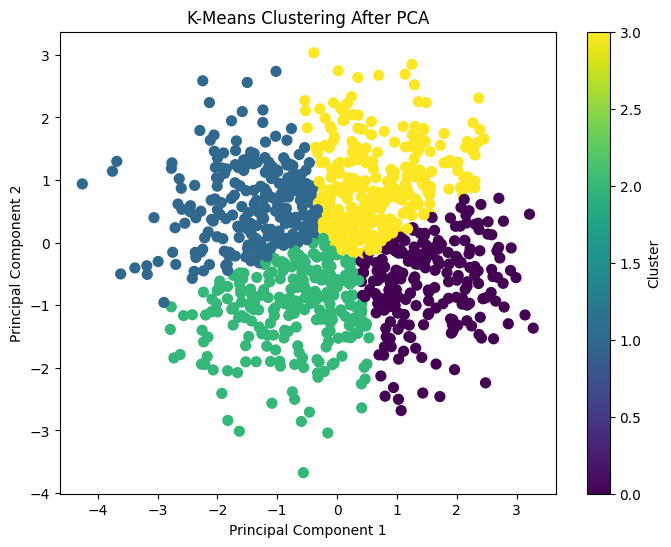

In [163]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['Cluster_PCA'],
    cmap='viridis',
    s=50
)

plt.title("K-Means Clustering After PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Cluster")

plt.show()

Observation:
After applying PCA, the clusters became easier to visualize in two dimensions. Although there is still some overlap between groups, the overall cluster structure remains distinguishable. PCA simplified the data while preserving the main clustering patterns.

# Comparison Before vs After PCA

| Aspect                   | Before PCA                                                 | After PCA                                                    |
| ------------------------ | ---------------------------------------------------------- | ------------------------------------------------------------ |
| **Data Used**            | Original scaled features (10 features)                     | PCA-transformed data (2 principal components)                |
| **Number of Features**   | 10                                                         | 2                                                            |
| **Cluster Sizes**        | 221, 275, 359, 145                                         | 219, 250, 253, 278                                           |
| **Visualization**        | Clusters overlapped and were less clear.                   | Clusters became more organized and easier to visualize.      |
| **Information Retained** | All original features were used (no dimensionality reduction).                   | About **29%** of the total variance was retained.            |
| **Interpretability**     | Provides more detailed cluster characteristics because all original features are preserved. | Easier to visualize and interpret, although some information is lost due to dimensionality reduction. |
| **Best Use**             | Better for clustering using all original features.                           | Better for visualization and dimensionality reduction.       |


# Discussion Questions

1. How did PCA affect clustering results?

> Applying PCA changed the clustering results because K-Means was performed on two principal components instead of the original features. As a result, some samples were assigned to different clusters, although the overall clustering patterns remained similar.

---

2. Did visualization become clearer?

> Yes. The visualization became clearer after PCA because the data was reduced to two principal components, making the clusters easier to display and interpret in a two-dimensional plot.

---

3. Did you lose important information?

> Yes. The first two principal components explained approximately **29%** of the total variance. This means that some information from the original dataset was lost during dimensionality reduction.

---

4. Which approach is better and why?

> For clustering accuracy, using the original scaled data is more suitable because it preserves all available information. However, PCA is better for visualization because it simplifies the data into two dimensions, making the cluster structure easier to understand.



# Bonus Challenge

In [164]:
pca3 = PCA(n_components=3)

X_pca3 = pca3.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca3.explained_variance_ratio_)
print("Total Explained Variance:", pca3.explained_variance_ratio_.sum())

Explained Variance Ratio: [0.17715118 0.11276247 0.10615588]
Total Explained Variance: 0.39606952412114366


In [165]:
kmeans3 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters3 = kmeans3.fit_predict(X_pca3)

print(pd.Series(clusters3).value_counts().sort_index())

0    220
1    251
2    208
3    321
Name: count, dtype: int64


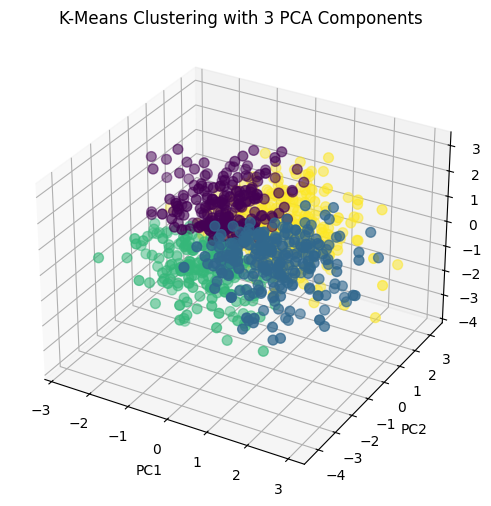

In [166]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca3[:,2],
    X_pca3[:,0],
    X_pca3[:,1],
    c=clusters3,
    cmap='viridis',
    s=50
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("K-Means Clustering with 3 PCA Components")

plt.show()

In [167]:
pca5 = PCA(n_components=5)

X_pca5 = pca5.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca5.explained_variance_ratio_)
print("Total Explained Variance:", pca5.explained_variance_ratio_.sum())

Explained Variance Ratio: [0.17715118 0.11276247 0.10615588 0.1025562  0.10190944]
Total Explained Variance: 0.6005351566604872


In [168]:
kmeans5 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters5 = kmeans5.fit_predict(X_pca5)

print(pd.Series(clusters5).value_counts().sort_index())

0    259
1    290
2    216
3    235
Name: count, dtype: int64


| PCA Components   | Total Explained Variance | Clustering Result                                                                                                   | Visualization                                                  | Recommendation                                                             |
| ---------------- | -----------------------: | ------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------- | -------------------------------------------------------------------------- |
| **2 Components** |               **28.99%** | Clusters changed after dimensionality reduction, but only a small portion of the original information was retained. | Excellent (2D visualization is simple and easy to interpret).  | Best for visualization.                                                    |
| **3 Components** |               **39.61%** | More information was retained, leading to a better representation of the original data compared to 2 components.    | Good (3D visualization is possible but slightly more complex). | Good balance between visualization and information retention.              |
| **5 Components** |               **60.05%** | Preserved much more information from the original dataset, providing a representation closer to the original data.  | Limited (cannot directly visualize all five components).       | Best for retaining information, but not suitable for simple visualization. |


Comparison Summary

As the number of PCA components increased, the amount of retained information also increased. Using 2 components preserved only 28.99% of the variance but provided the clearest two-dimensional visualization. Using 3 components improved the retained variance to 39.61%, offering a better balance between visualization and information preservation. Using 5 components retained approximately 60.05% of the original variance, making it the best option for preserving information; However, using five principal components makes direct visualization difficult because only two- or three-dimensional plots can be displayed effectively.